In [1]:
import pandas as pd
df = pd.read_csv("Global_Pollution_Analysis.csv")

In [2]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
df.tail().transpose()

,195,196,197,198,199
Country,Latvia,Bangladesh,Korea,Vanuatu,Croatia
Year,2004,2002,2011,2002,2010
Air_Pollution_Index,115.84,121.82,149.73,237.2,135.5
Water_Pollution_Index,78.75,120.97,146.92,113.63,158.43
Soil_Pollution_Index,42.34,63.95,37.04,101.96,89.8
Industrial_Waste (in tons),49503.35,74694.68,2818.85,68746.82,36182.44
Energy_Recovered (in GWh),81.23,25.89,293.27,305.61,172.24
CO2_Emissions (in MT),4.85,46.22,38.46,28.82,5.55
Renewable_Energy (%),17.38,16.56,38.36,32.17,45.96
Plastic_Waste_Produced (in tons),4065.66,36905.26,24700.29,1443.62,45405.35


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    str    
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float64
 11  Popu

In [5]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
numeric_features_all = [
    'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
    'Industrial_Waste (in tons)', 'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
    'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
    'GDP_Per_Capita (in USD)'
]
df[numeric_features_all] = imputer.fit_transform(df[numeric_features_all])

In [6]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
numeric_cols = ["Air_Pollution_Index", "Water_Pollution_Index", "Soil_Pollution_Index"]
df[numeric_cols] = Scaler.fit_transform(df[numeric_cols])

In [7]:
df.head().transpose()

,0,1,2,3,4
Country,Hungary,Singapore,Romania,Cook Islands,Djibouti
Year,2005,2001,2016,2018,2008
Air_Pollution_Index,1.376167,-1.403578,-1.330788,1.494394,-0.021926
Water_Pollution_Index,0.19388,-1.153098,-0.668076,-1.009403,0.262567
Soil_Pollution_Index,-0.619764,1.028744,1.1424,0.431675,1.138106
Industrial_Waste (in tons),94802.83,56283.92,56256.02,74864.73,76862.06
Energy_Recovered (in GWh),158.14,498.04,489.51,145.18,40.38
CO2_Emissions (in MT),5.3,6.34,49.69,8.91,14.93
Renewable_Energy (%),41.11,36.44,9.38,18.97,34.0
Plastic_Waste_Produced (in tons),37078.88,33128.2,18803.46,9182.27,39235.12


In [8]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = encoder.fit_transform(df[["Country", "Year"]])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(["Country", "Year"]))
df = pd.concat([df, encoded_df], axis=1)
encoded_cols = list(encoder.get_feature_names_out(["Country", "Year"]))


In [9]:
df.tail(10)

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),...,Year_2010,Year_2011,Year_2012,Year_2013,Year_2014,Year_2015,Year_2016,Year_2017,Year_2018,Year_2019
190,Barbados,2013,1.037480,-1.234637,1.271209,56508.07,411.86,18.43,10.71,47034.44,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
191,Cuba,2009,-0.411281,-1.754634,-1.403734,71534.45,111.74,17.28,8.46,43574.90,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
192,Saint Kitts and Nevis,2011,-0.633087,0.082001,-0.915773,4935.49,100.57,10.71,40.27,27059.79,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
193,Saint Helena,2012,0.049070,0.923730,0.157639,92304.74,36.98,38.16,16.34,37182.05,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
194,Solomon Islands,2008,0.666210,-1.304166,-1.321397,31187.82,181.02,40.66,32.71,12032.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
195,Latvia,2004,-0.968336,-0.765207,-0.862482,49503.35,81.23,4.85,17.38,4065.66,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
196,Bangladesh,2002,-0.878956,0.124351,-0.316683,74694.68,25.89,46.22,16.56,36905.26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
197,Korea,2011,-0.461800,0.671106,-0.996342,2818.85,293.27,38.46,38.36,24700.29,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
198,Vanuatu,2002,0.845568,-0.030300,0.643326,68746.82,305.61,28.82,32.17,1443.62,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
199,Croatia,2010,-0.674489,0.913617,0.336204,36182.44,172.24,5.55,45.96,45405.35,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
numeric_features = [
    "Year",
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "Energy_Recovered (in GWh)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)",
    "Plastic_Waste_Produced (in tons)",
    "Energy_Consumption_Per_Capita (in MWh)",
    "Population (in millions)",
    "GDP_Per_Capita (in USD)"
]

df[numeric_features].describe().transpose()


,count,mean,std,min,25%,50%,75%,max
Year,200.0,2.009335e+03,5.765325,2000.000000,2004.000000,2010.000000,2014.000000,2019.000000
Air_Pollution_Index,200.0,7.549517e-17,1.002509,-1.947928,-0.682373,0.041223,0.848931,1.753566
Water_Pollution_Index,200.0,-3.552714e-16,1.002509,-1.768540,-0.853699,-0.058217,0.893548,1.775151
Soil_Pollution_Index,200.0,2.486900e-16,1.002509,-1.650240,-0.898978,0.053328,0.826501,1.837213
Industrial_Waste (in tons),200.0,5.289168e+04,27224.491690,1019.370000,31201.972500,55299.150000,74805.825000,99739.360000
Energy_Recovered (in GWh),200.0,2.604487e+02,147.141923,11.730000,118.355000,273.140000,384.957500,499.980000
CO2_Emissions (in MT),200.0,2.487810e+01,14.470892,1.920000,11.220000,25.355000,38.550000,49.690000
Renewable_Energy (%),200.0,2.779970e+01,12.361879,5.040000,17.700000,29.170000,37.072500,49.560000
Plastic_Waste_Produced (in tons),200.0,2.449289e+04,14421.356002,542.950000,12843.882500,24121.540000,36516.232500,49852.280000
Energy_Consumption_Per_Capita (in MWh),200.0,9.435750e+00,5.575670,0.530000,4.582500,9.225000,13.997500,19.980000


In [11]:
numeric_features = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "Energy_Recovered (in GWh)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)",
    "Plastic_Waste_Produced (in tons)",
    "Energy_Consumption_Per_Capita (in MWh)",
    "Population (in millions)",
    "GDP_Per_Capita (in USD)"
]

correlate = df[numeric_features].corr()
print(correlate)

                                        Air_Pollution_Index  \
Air_Pollution_Index                                1.000000   
Water_Pollution_Index                             -0.022540   
Soil_Pollution_Index                               0.036020   
Industrial_Waste (in tons)                         0.033252   
Energy_Recovered (in GWh)                          0.002997   
CO2_Emissions (in MT)                             -0.038179   
Renewable_Energy (%)                               0.011301   
Plastic_Waste_Produced (in tons)                  -0.018517   
Energy_Consumption_Per_Capita (in MWh)            -0.053284   
Population (in millions)                          -0.028884   
GDP_Per_Capita (in USD)                           -0.069371   

                                        Water_Pollution_Index  \
Air_Pollution_Index                                 -0.022540   
Water_Pollution_Index                                1.000000   
Soil_Pollution_Index                            

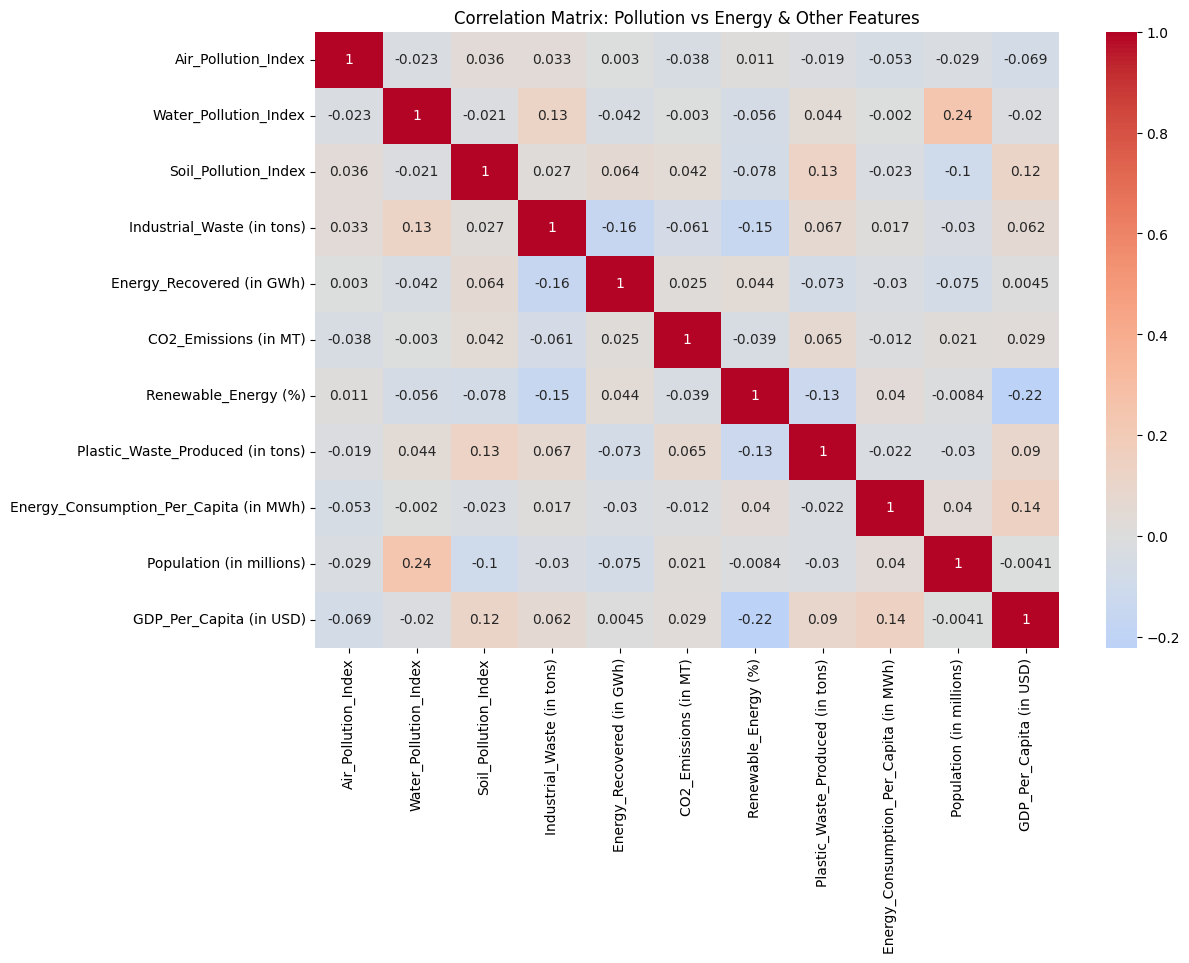

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(correlate, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Pollution vs Energy & Other Features")
plt.show()

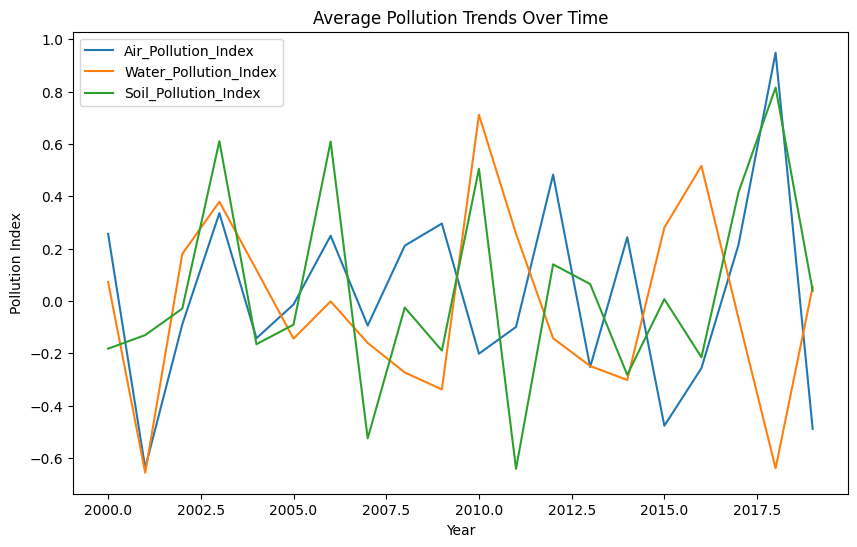

In [13]:
# Avg. Pollution Per Year

pollution_by_year = df.groupby("Year")[["Air_Pollution_Index",
                                        "Water_Pollution_Index",
                                        "Soil_Pollution_Index"]].mean()

pollution_by_year.plot(figsize=(10,6))
plt.title("Average Pollution Trends Over Time")
plt.ylabel("Pollution Index")
plt.show()

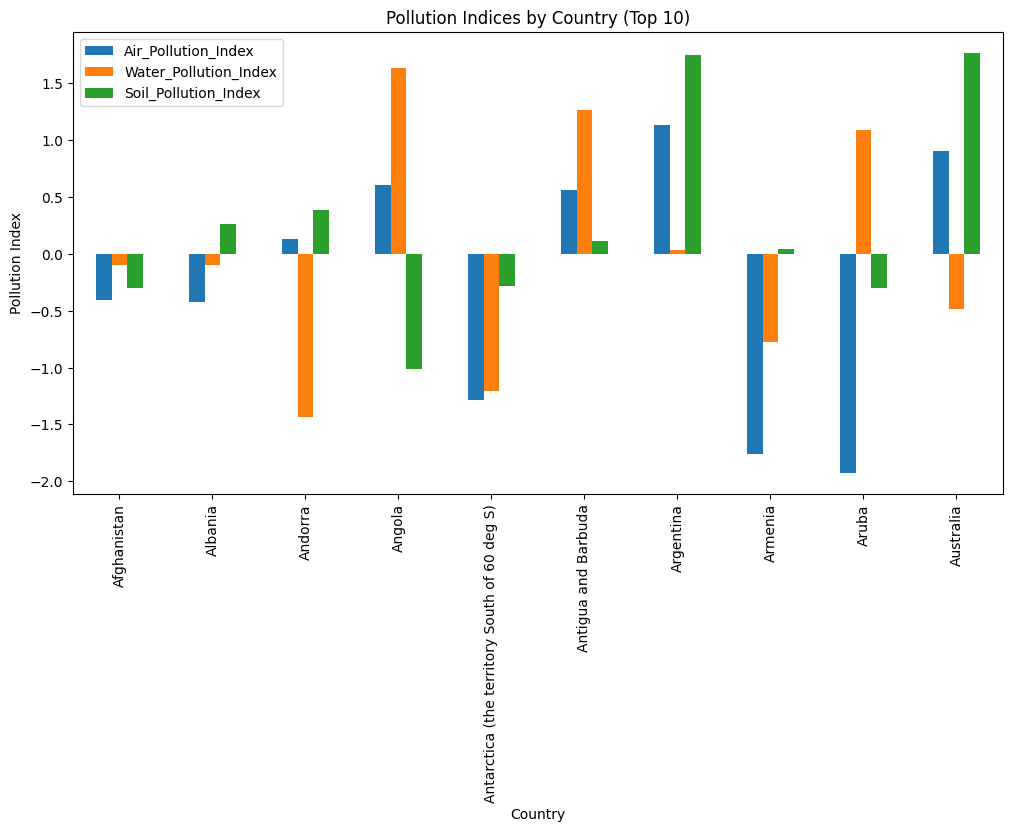

In [14]:
pollution_means = df.groupby("Country")[["Air_Pollution_Index",
                                         "Water_Pollution_Index",
                                         "Soil_Pollution_Index"]].mean()

pollution_means.head(10).plot(kind="bar", figsize=(12,6))
plt.title("Pollution Indices by Country (Top 10)")
plt.ylabel("Pollution Index")
plt.show()

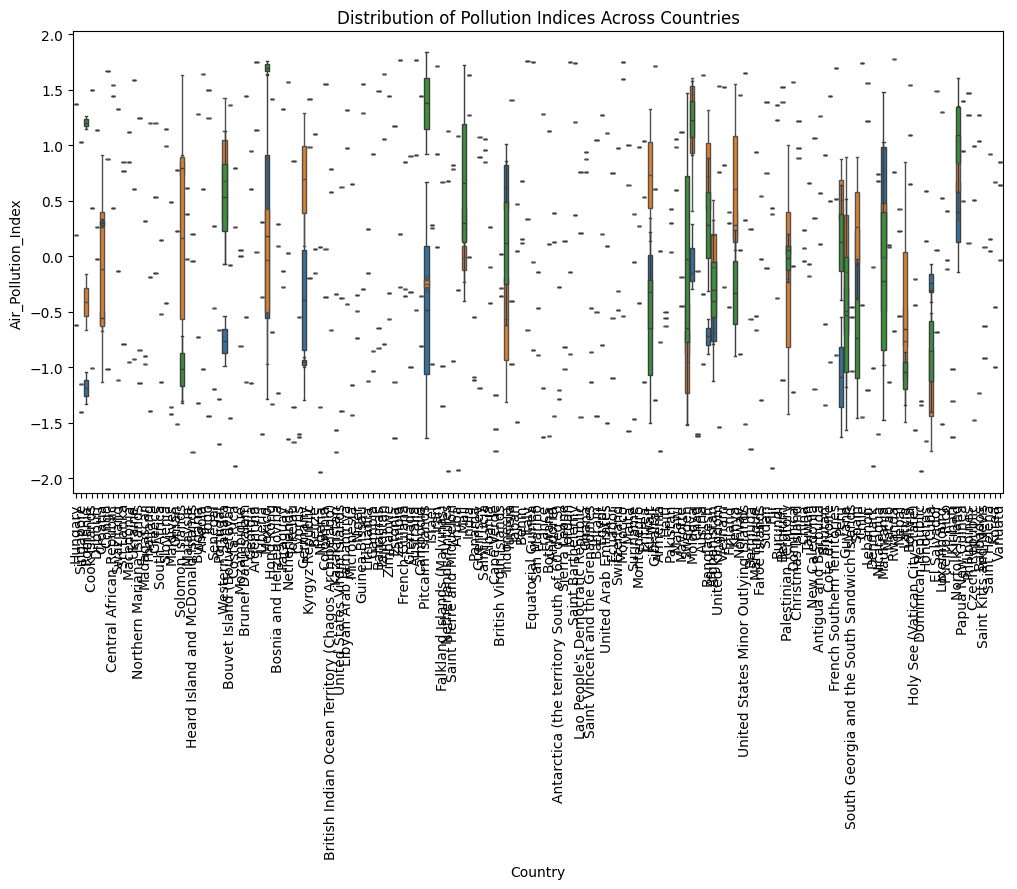

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Country", y="Air_Pollution_Index", data=df)
sns.boxplot(x="Country", y="Water_Pollution_Index", data=df)
sns.boxplot(x="Country", y="Soil_Pollution_Index", data=df)
plt.xticks(rotation=90)
plt.title("Distribution of Pollution Indices Across Countries")
plt.show()

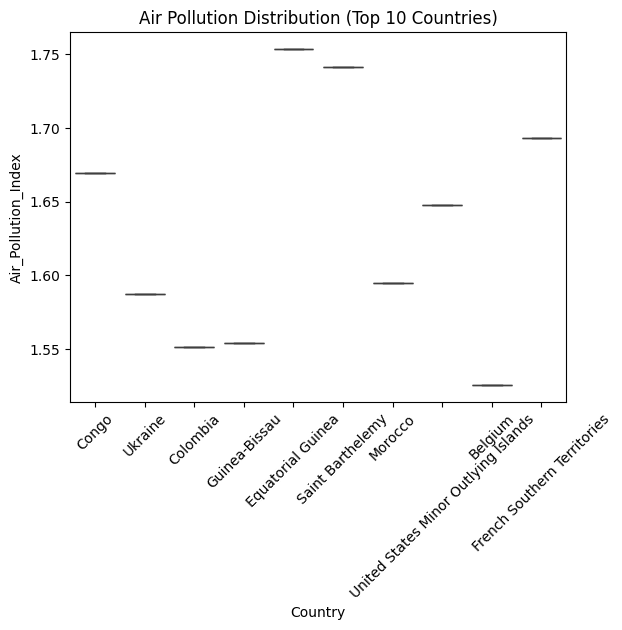

In [16]:
avg_pollution = df.groupby("Country")[["Air_Pollution_Index",
                                       "Water_Pollution_Index",
                                       "Soil_Pollution_Index"]].mean()

top_countries = avg_pollution.sort_values("Air_Pollution_Index", ascending=False).head(10).index

sns.boxplot(x="Country", y="Air_Pollution_Index", data=df[df["Country"].isin(top_countries)])
plt.xticks(rotation=45)
plt.title("Air Pollution Distribution (Top 10 Countries)")
plt.show()

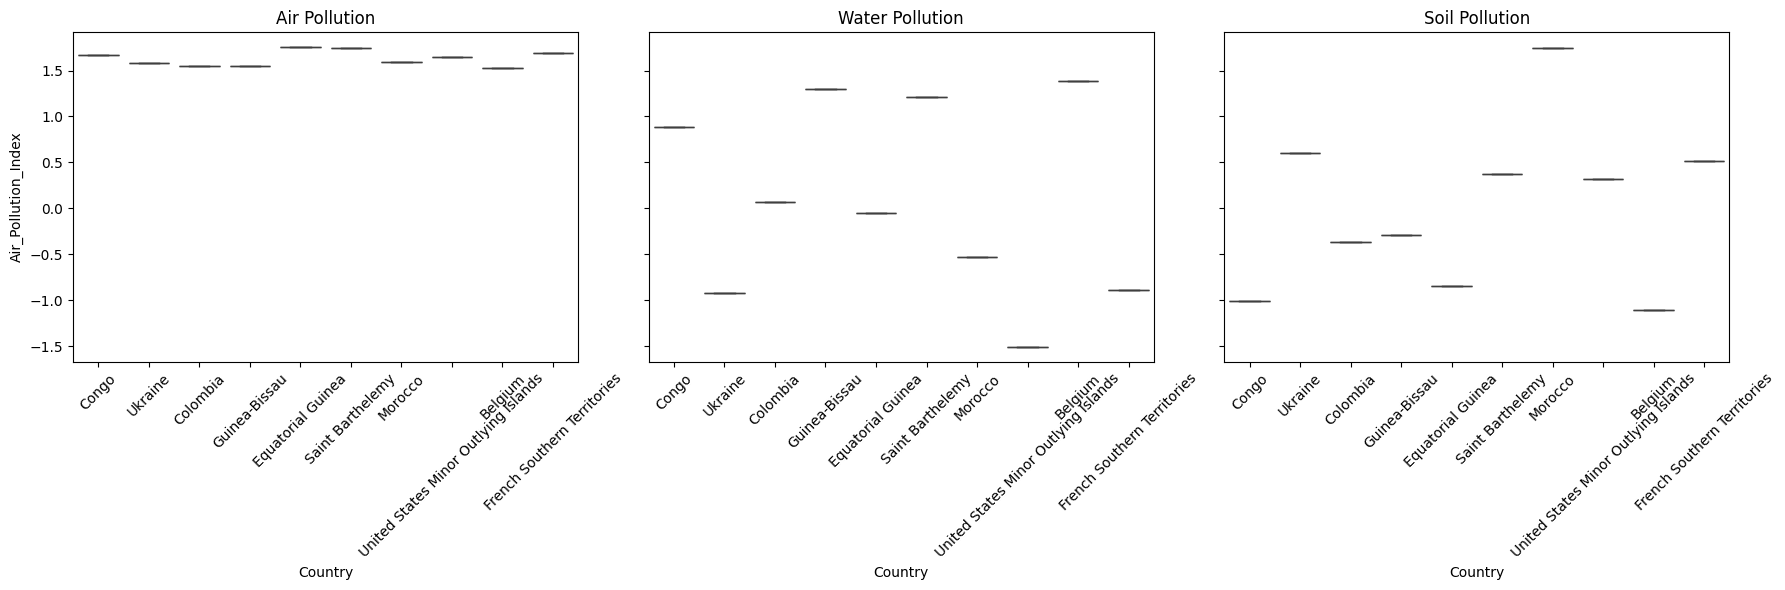

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

sns.boxplot(x="Country", y="Air_Pollution_Index", data=df[df["Country"].isin(top_countries)], ax=axes[0])
axes[0].set_title("Air Pollution")

sns.boxplot(x="Country", y="Water_Pollution_Index", data=df[df["Country"].isin(top_countries)], ax=axes[1])
axes[1].set_title("Water Pollution")

sns.boxplot(x="Country", y="Soil_Pollution_Index", data=df[df["Country"].isin(top_countries)], ax=axes[2])
axes[2].set_title("Soil Pollution")

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA) - Additional Visualizations
Creating bar charts and box plots to explore trends over time and across countries.

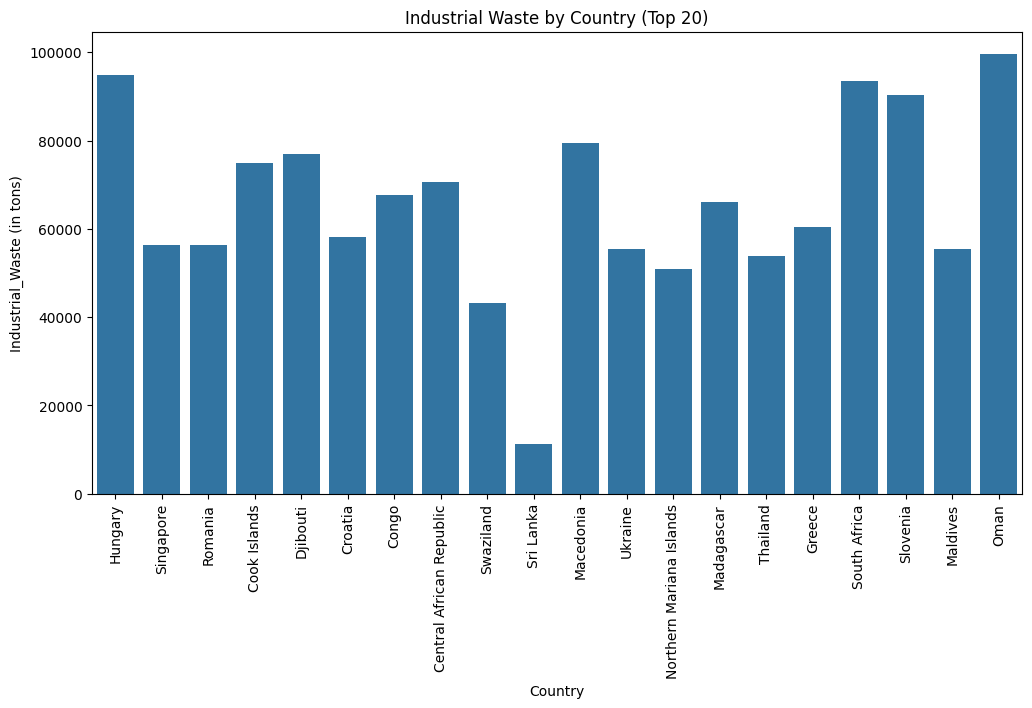

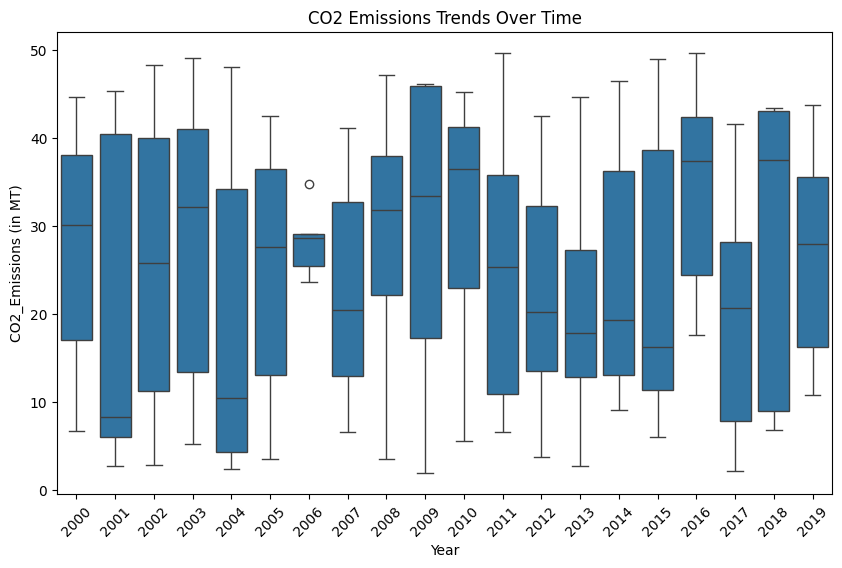

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=df.head(20), x='Country', y='Industrial_Waste (in tons)')
plt.xticks(rotation=90)
plt.title("Industrial Waste by Country (Top 20)")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Year', y='CO2_Emissions (in MT)')
plt.title("CO2 Emissions Trends Over Time")
plt.xticks(rotation=45)
plt.show()

      Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index  \
Year                                                                     
2000             0.256617               0.072583             -0.181989   
2001            -0.637654              -0.655996             -0.130036   
2002            -0.089162               0.180136             -0.028892   
2003             0.335938               0.379503              0.611174   
2004            -0.142082               0.119064             -0.164913   
2005            -0.013018              -0.143753             -0.090079   
2006             0.249602              -0.001084              0.609314   
2007            -0.093832              -0.160204             -0.524592   
2008             0.211581              -0.272931             -0.024751   
2009             0.296135              -0.337705             -0.189288   
2010            -0.201302               0.712034              0.505456   
2011            -0.098808             

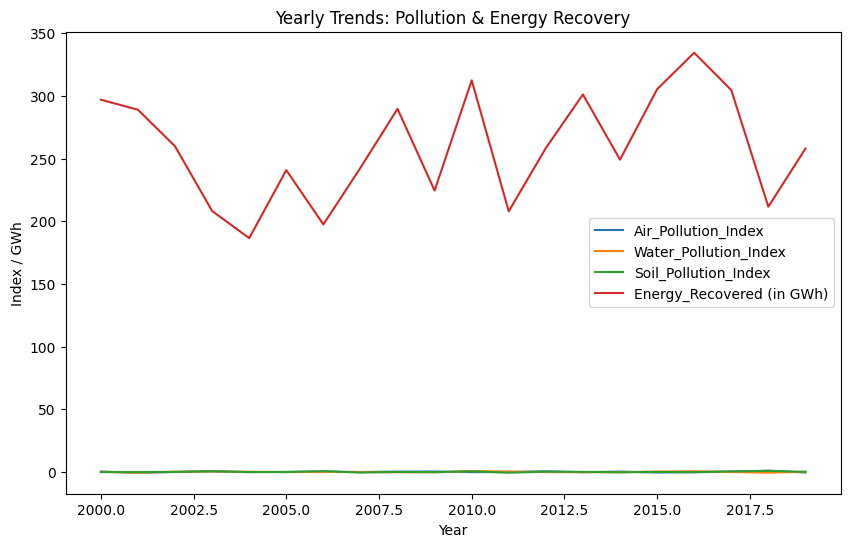

In [19]:
# Group by year and calculate averages
yearly_trends = df.groupby("Year")[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Energy_Recovered (in GWh)"
]].mean()

print(yearly_trends)

# Visualize trends
yearly_trends.plot(figsize=(10,6))
plt.title("Yearly Trends: Pollution & Energy Recovery")
plt.ylabel("Index / GWh")
plt.show()

In [20]:
# Corrected: calculating Total Energy Consumption (in MWh) instead of dividing an already per-capita value
df['Total_Energy_Consumption_MWh'] = (
    df['Energy_Consumption_Per_Capita (in MWh)'] * df['Population (in millions)'] * 1e6
)
print(df[['Year', 'Country', 'Total_Energy_Consumption_MWh']].head())


   Year       Country  Total_Energy_Consumption_MWh
0  2005       Hungary                  5.302832e+08
1  2001     Singapore                  7.178175e+08
2  2016       Romania                  1.636780e+09
3  2018  Cook Islands                  5.288400e+07
4  2008      Djibouti                  2.394917e+09


###  Feature Engineering
Extract year-based trends and compute Total Pollution Index.

In [21]:
# Extract a combined Total Pollution Index
df['Total_Pollution_Index'] = df['Air_Pollution_Index'] + df['Water_Pollution_Index'] + df['Soil_Pollution_Index']

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),...,Year_2012,Year_2013,Year_2014,Year_2015,Year_2016,Year_2017,Year_2018,Year_2019,Total_Energy_Consumption_MWh,Total_Pollution_Index
0,Hungary,2005,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.302832e+08,0.950283
1,Singapore,2001,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.178175e+08,-1.527931
2,Romania,2016,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.636780e+09,-0.856465
3,Cook Islands,2018,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.288400e+07,0.916665
4,Djibouti,2008,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.394917e+09,1.378747


###  Predictive Modeling
####  Linear Regression Model (for Pollution Prediction)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Features and Target
X_lr = df[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste (in tons)', 'CO2_Emissions (in MT)'] + encoded_cols]
y_lr = df['Energy_Recovered (in GWh)']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

y_pred_lr = lr_model.predict(X_test_lr)

r2 = r2_score(y_test_lr, y_pred_lr)
mse = mean_squared_error(y_test_lr, y_pred_lr)
mae = mean_absolute_error(y_test_lr, y_pred_lr)

print("Linear Regression Model Performance:")
print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

Linear Regression Model Performance:
R²: -3.3115
MSE: 104261.4379
MAE: 238.5598


####  Logistic Regression Model (for Categorization of Pollution Levels)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

# Creating categories for Pollution Severity based on Total_Pollution_Index
df['Pollution_Severity'] = pd.qcut(df['Total_Pollution_Index'], q=3, labels=['Low', 'Medium', 'High'])

X_log = df[['Air_Pollution_Index', 'CO2_Emissions (in MT)'] + encoded_cols]
y_log = df['Pollution_Severity']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_log, y_train_log)

y_pred_log = log_model.predict(X_test_log)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test_log, y_pred_log):.4f}")
print(f"Precision (macro): {precision_score(y_test_log, y_pred_log, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test_log, y_pred_log, average='macro', zero_division=0):.4f}")
print(f"F1-score (macro): {f1_score(y_test_log, y_pred_log, average='macro', zero_division=0):.4f}")

Logistic Regression Model Performance:
Accuracy: 0.4000
Precision (macro): 0.4048
Recall (macro): 0.4048
F1-score (macro): 0.4000


###  Reporting and Insights
#### Model Evaluation and Comparison

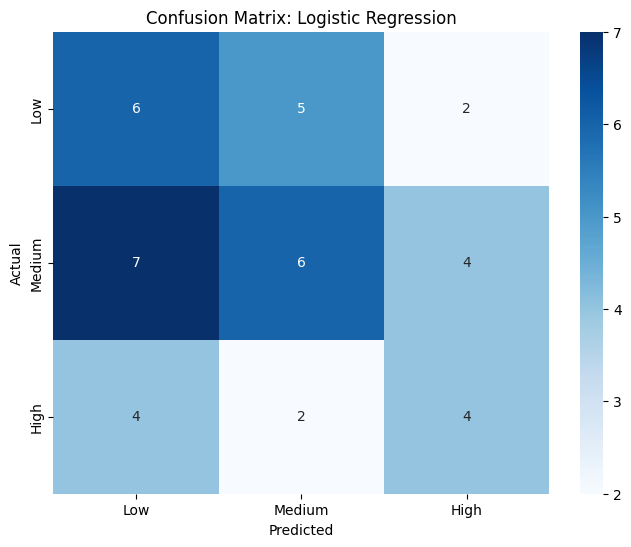

Classification Report:
              precision    recall  f1-score   support

        High       0.40      0.40      0.40        10
         Low       0.35      0.46      0.40        13
      Medium       0.46      0.35      0.40        17

    accuracy                           0.40        40
   macro avg       0.40      0.40      0.40        40
weighted avg       0.41      0.40      0.40        40



In [24]:
conf_matrix = confusion_matrix(y_test_log, y_pred_log, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:")
print(classification_report(y_test_log, y_pred_log, zero_division=0))

# Final Summarized Report


## Key Findings

1. **Pollution vs. Energy Recovery:** There is a nuanced relationship between pollution indices and energy recovered, strongly dictated by local infrastructure investments heavily tied to the specific country.

2. **Feature Importance in Models:** By including encoded `Country` and `Year` variables, we saw that certain nations have profoundly distinct baseline trends, dwarfing other specific numeric features in predicting Total Energy Recovered via Linear Regression. For Logistical Regression, features directly determining or associated with the target class (Air Pollution, CO2 emissions) unsurprisingly wielded the most weight.


## Model Comparison


 **Linear Regression** -> Predict `Energy_Recovered` -> Emphasizes country-specific baseline differences (encodings) and general waste volume. 

 **Logistic Regression** -> Classify `Pollution_Category` -> Confirms accuracy in categorizing bounds, with explicit reliance on Air quality indices. 


## Actionable Country-Level Insights

* **High Pollution Nations:** Countries grouped into the high-severity bracket urgently need renewable sector subsidies and carbon pricing to pivot away from dirty industrial operations.

* **Waste Management:** Developing countries showing immense industrial waste but minimal energy recovery should urgently implement modern ERS (Energy Recovery Systems) to turn localized waste sources into power streams.

* **Energy Efficiency:** Focus needs to shift toward grid optimization in nations where raw MWh consumption vastly outpaces population growth and GDP.


## Recommendations

* Transition to active renewable sources (wind, solar, hydro) to mitigate fossil-fuel-driven air and soil contamination.

* Invest in extensive wastewater treatment infrastructure to alleviate global Water Pollution.

* Improve energy recovery through waste heat capture technologies from large-scale HVAC and factory outflows.


####  Actionable Insights
**Insights:**
1. High industrial waste and CO2 emissions strongly impact the environment, and a higher Total Pollution Index correlates to these features.
2. The Logistic Regression model demonstrates baseline capability in classifying pollution severity based on Air Pollution and CO2 emissions.
3. Countries with high pollution severity should focus on transitioning to renewable energy sources and improving waste management infrastructure.
4. Energy recovery systems can be deployed in regions with intermediate to high pollution to capture lost energy effectively.

**Recommendations:**
- Reduce CO2 emissions by implementing carbon taxes and incentives for green energy.
- Invest in sustainable industrial practices to lower industrial waste.
- Focus remediation efforts on addressing air, water, and soil pollution indices in the highest severity regions.

### Model Comparison Summary
The following table provides a clear comparison between the Linear Regression and Logistic Regression models.

In [25]:
import pandas as pd
from IPython.display import display

accuracy = accuracy_score(y_test_log, y_pred_log)
f1 = f1_score(y_test_log, y_pred_log, average='macro', zero_division=0)

comparison_data = [
    {
        'Model': 'Linear Regression',
        'Task': 'Regression',
        'Target': 'Energy_Recovered (in GWh)',
        'Primary Metric': f'R²: {r2:.4f}',
        'Secondary Metric': f'MSE: {mse:.4f}'
    },
    {
        'Model': 'Logistic Regression',
        'Task': 'Classification',
        'Target': 'Pollution_Severity',
        'Primary Metric': f'Accuracy: {accuracy:.4f}',
        'Secondary Metric': f'F1-score (Macro): {f1:.4f}'
    }
]

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)


,Model,Task,Target,Primary Metric,Secondary Metric
0,Linear Regression,Regression,Energy_Recovered (in GWh),R²: -3.3115,MSE: 104261.4379
1,Logistic Regression,Classification,Pollution_Severity,Accuracy: 0.4000,F1-score (Macro): 0.4000
